# Taller de analítica educativa e interpretabilidad con LIME y SHAP
## Guía de trabajo sobre una base real

Este cuaderno está diseñado como una **ruta de trabajo**.  
No contiene el desarrollo resuelto ni el código de implementación.

La idea es que, a partir de las instrucciones, se construya el análisis paso a paso sobre la base real compartida por el docente.

---

## Propósito del taller

Desarrollar un análisis completo que permita:

- comprender la estructura de una base real,
- identificar correctamente la unidad de análisis,
- transformar la base de manera metodológicamente adecuada,
- realizar análisis exploratorio,
- construir modelos de clasificación y regresión,
- interpretar resultados con LIME y SHAP,
- y discutir limitaciones, fuga de información y utilidad real del modelo.

---

## Regla general de trabajo

En cada sección hay:

- una **explicación de la tarea**,
- una o varias **preguntas orientadoras**,
- y luego un **espacio de trabajo**.

En los espacios de trabajo se espera que se escriba el código, los comentarios y las respuestas necesarias.

## Información de la fuente de datos

La base de trabajo proviene de un archivo compartido por Google Sheets.

El enlace de acceso es:

`https://docs.google.com/spreadsheets/d/1LqTPK6Yt7eVPHbERfSBfPHyhZXayjFbo/edit?usp=sharing&ouid=104978049265234234691&rtpof=true&sd=true`

---

## Primera decisión técnica

Antes de comenzar, se debe decidir cómo cargar los datos en Colab.

### Preguntas orientadoras

1. ¿Qué opciones existen para leer un Google Sheet desde Python?
2. ¿Conviene leerlo como CSV exportado o usar otra estrategia?
3. ¿Qué validaciones se deben hacer para comprobar que la carga fue correcta?

### Tarea

Implementar la carga de la base y mostrar una vista inicial del archivo.

In [20]:
import pandas as pd
csv_url = "https://docs.google.com/spreadsheets/d/1LqTPK6Yt7eVPHbERfSBfPHyhZXayjFbo/export?format=csv"
df=pd.read_csv(csv_url)
df.head()

,Sede,ID Estudiante,Edad Estudiante,Genero,Grado,Curso,Antiguedad,Prueba,Acierto,QuestionId,Pregunta,AnswerId,Respuesta,Competencia,Nota en prueba,Aprobó
0,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5115,Martín es un jugador de voleibol que ganó el 5...,22859,40 juegos.,Resolución de problemas,"85,00%",1
1,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5116,Observa las notas obtenidas por Carlos en sus ...,22862,"3,7",Resolución de problemas,"85,00%",1
2,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5117,La tabla relaciona la cantidad de medallas obt...,22867,NaN,Comunicación,"85,00%",1
3,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5118,"En una fábrica de zapatos, el número de zapato...",22868,NaN,Comunicación,"85,00%",1
4,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5119,"En un juego de tablero, las fichas se ubican c...",22874,"(H, 3)",Comunicación,"85,00%",1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209815 entries, 0 to 209814
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   Sede             209815 non-null  str  
 1   ID Estudiante    209815 non-null  str  
 2   Edad Estudiante  209815 non-null  int64
 3   Genero           209815 non-null  str  
 4   Grado            209815 non-null  str  
 5   Curso            209815 non-null  str  
 6   Antiguedad       209815 non-null  int64
 7   Prueba           209815 non-null  str  
 8   Acierto          209815 non-null  int64
 9   QuestionId       209815 non-null  int64
 10  Pregunta         208860 non-null  str  
 11  AnswerId         209815 non-null  int64
 12  Respuesta        195963 non-null  str  
 13  Competencia      209815 non-null  str  
 14  Nota en prueba   209815 non-null  str  
 15  Aprobó           209815 non-null  int64
dtypes: int64(6), str(10)
memory usage: 25.6 MB


Las variables que describen al estudiante son: Sede, ID Estudiante, Edad estudiantes, Genero, Grado, Curso y Antiguedad.

Las variables que describen la prueba son: Prueba, Competencia.

Las variables que describen preguntas o respuestas: Pregunta, AnswerID, QuestionID, Respuesta

Las variables que representan resultados finales son: Nota en prueba y Aprobó

La base tiene 16 variables y 209815 filas, con 2393 estudiantes, con 35 pruebas, se evaluan 22 competencias y 697 preguntas

In [3]:
len(set(df["ID Estudiante"]))

2393

In [4]:
len(set(df["Prueba"]))

35

In [5]:
len(set(df["Competencia"]))

22

In [6]:
len(set(df["QuestionId"]))

697

Cada fila representa la respuesta de un estudiante a una pregunta

In [7]:
len(set(df["AnswerId"]))

2745

Es como prueba estatal, la cual se le realizo a diferentes colegios, la cual contiene por estudiante las preguntas y respuestas relacionadas a la prueba.

# Parte 1. Diagnóstico de la base original

## Objetivo

Comprender qué representa cada fila y cómo está organizada la base.

Antes de modelar, es indispensable responder una pregunta central:

> ¿Cuál es la unidad de observación original de esta base?

---

## Tareas

1. Revisar las columnas disponibles.
2. Identificar cuáles variables describen al estudiante.
3. Identificar cuáles variables describen la prueba.
4. Identificar cuáles variables describen preguntas o respuestas.
5. Identificar cuáles variables representan resultados finales.
6. Calcular dimensiones generales de la base.
7. Estimar cuántos estudiantes, pruebas, preguntas y competencias hay.

### Preguntas orientadoras

- ¿Cada fila representa un estudiante?
- ¿Cada fila representa una prueba completa?
- ¿O cada fila representa una respuesta a una pregunta?

### Producto esperado

Un diagnóstico breve y una primera interpretación escrita de la estructura del archivo.

## Verificación de la unidad de análisis

Para confirmar la unidad de observación, se debe analizar cuántas filas corresponden a una misma combinación de:

- estudiante
- prueba

### Tareas

1. Agrupar por estudiante y prueba.
2. Contar cuántas filas aparecen dentro de cada grupo.
3. Describir el comportamiento de ese conteo.
4. Interpretar qué significa ese resultado.

### Preguntas orientadoras

- Si un mismo estudiante en una misma prueba aparece en varias filas, ¿qué implica eso?
- ¿Qué error metodológico ocurriría si se tratara cada fila como si fuera un estudiante completo?

### Producto esperado

Una justificación clara de por qué la base original no debe modelarse directamente como si cada fila fuera un caso final independiente.

## Consistencia interna de variables finales

Una vez identificada la unidad de análisis, se debe revisar si algunas variables finales se mantienen consistentes dentro de cada combinación estudiante-prueba.

### Variables sugeridas para revisar

- nota final de la prueba
- aprobación

### Tareas

1. Verificar si estas variables toman un único valor por cada estudiante-prueba.
2. Identificar posibles inconsistencias.
3. Discutir si las inconsistencias encontradas afectan el análisis.

### Preguntas orientadoras

- ¿La nota final cambia dentro del mismo estudiante-prueba?
- ¿La aprobación cambia dentro del mismo estudiante-prueba?
- Si cambia, ¿qué hipótesis podrían explicar ese problema?

### Producto esperado

Una nota metodológica sobre la calidad y consistencia de los datos.

# Parte 2. Análisis exploratorio

## Objetivo

Describir patrones importantes en la base antes de entrenar modelos.

---

## Tareas mínimas

1. Analizar la distribución de la nota final.
2. Analizar la distribución de aprobación.
3. Comparar desempeño promedio por grado.
4. Comparar desempeño promedio por prueba.
5. Identificar diferencias entre grupos relevantes.
6. Formular hipótesis a partir de los patrones observados.

### Requisito

Se deben construir al menos **tres visualizaciones** y acompañarlas con interpretación escrita.

### Preguntas orientadoras

- ¿La distribución de notas está concentrada o dispersa?
- ¿La aprobación está balanceada?
- ¿Qué pruebas parecen más difíciles?
- ¿Existen diferencias visibles entre grados, sedes o cursos?

### Producto esperado

Una sección descriptiva con gráficos y hallazgos.

In [ ]:
import pandas as pd

csv_url = "https://docs.google.com/spreadsheets/d/1LqTPK6Yt7eVPHbERfSBfPHyhZXayjFbo/export?format=csv"
df = pd.read_csv(csv_url)

In [24]:
df["Nota en prueba"] = (
    df["Nota en prueba"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
)

df["Nota en prueba"] = pd.to_numeric(df["Nota en prueba"], errors="coerce")

In [25]:
df["Nota en prueba"].describe()

count    209815.000000
mean         59.946704
std          20.458523
min           0.000000
25%          45.000000
50%          60.000000
75%          75.000000
max         100.000000
Name: Nota en prueba, dtype: float64

## 1. Distribución de la nota final

En esta sección se analiza la distribución de las notas finales obtenidas por los estudiantes en las pruebas. Este análisis permite observar la concentración de los resultados, identificar posibles sesgos en la distribución y evaluar la variabilidad del desempeño académico.

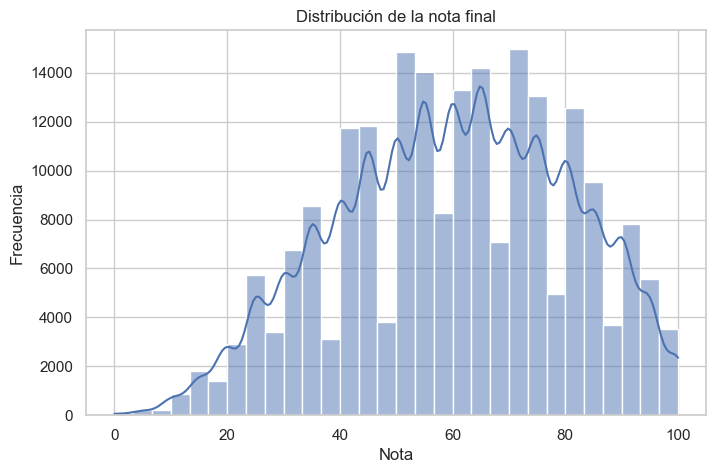

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["Nota en prueba"], bins=30, kde=True)

plt.title("Distribución de la nota final")
plt.xlabel("Nota")
plt.ylabel("Frecuencia")

plt.show()

El histograma de la nota final tiene una distribución con mayor concentración de valores entre 50 y 80 puntos. El pico principal de la distribución se ubica entre 60 y 70, lo cual coincide con el promedio calculado previamente.

La forma de la curva indica que la mayor parte de los estudiantes obtiene calificaciones medias, mientras que los valores extremos tienen menor frecuencia. Esto sugiere una variabilidad moderada en el desempeño académico, con estudiantes distribuidos en distintos niveles de rendimiento.

## 2. Distribución de aprobación

Se analiza la proporción de estudiantes que aprobaron o reprobaron la prueba. Este análisis es importante para entender si el conjunto de datos presenta un balance entre ambas clases, lo cual puede influir en el entrenamiento de modelos de clasificación.

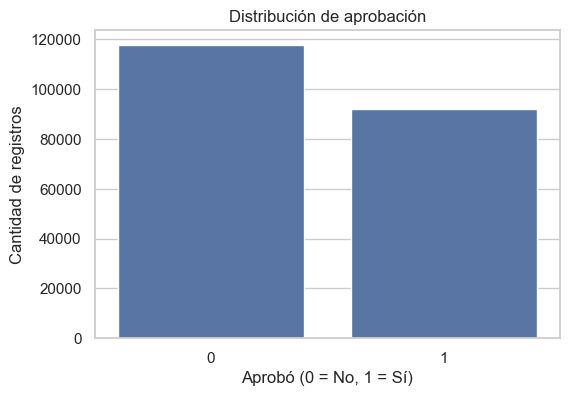

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x="Aprobó", data=df)

plt.title("Distribución de aprobación")
plt.xlabel("Aprobó (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de registros")

plt.show()

El gráfico de distribución de aprobación muestra la proporción de estudiantes que aprobaron (1) frente a aquellos que no aprobaron (0).

Se observa que la cantidad de estudiantes que no aprueban es mayor que la de quienes aprueban. Sin embargo, la diferencia entre ambas categorías no es tan alta, lo que indica que el conjunto de datos presenta una distribución balanceada entre aprobados y reprobados.

## 3. Comparación del desempeño promedio por grado

En esta sección se analiza el promedio de las notas de los estudiantes según el grado académico. Esto permite identificar posibles diferencias en el rendimiento entre los distintos niveles educativos.

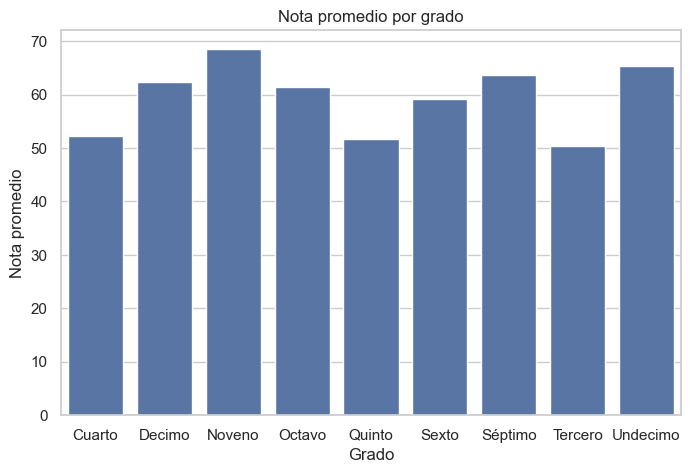

In [30]:
nota_grado = df.groupby("Grado")["Nota en prueba"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=nota_grado, x="Grado", y="Nota en prueba")

plt.title("Nota promedio por grado")
plt.xlabel("Grado")
plt.ylabel("Nota promedio")

plt.show()

El análisis del desempeño promedio por grado revela diferencias entre los niveles educativos. Algunos grados presentan promedios cercanos o superiores a 65–70 puntos, mientras que otros se sitúan alrededor de 50–55 puntos.

En grados como Noveno y Undécimo presentan promedios relativamente más altos, lo que podría indicar un mayor nivel de preparación académica o mayor familiaridad con el tipo de evaluación aplicada. Por otro lado, grados como Tercero y Quinto muestran promedios más bajos, lo cual puede deberse a la dificultad relativa del contenido evaluado o al nivel de desarrollo académico esperado en esos niveles.

## 4. Comparación del desempeño promedio por prueba

En esta sección se analiza el promedio de las notas según el tipo de prueba aplicada. Esto permite identificar evaluaciones que presentan mayor o menor dificultad para los estudiantes.

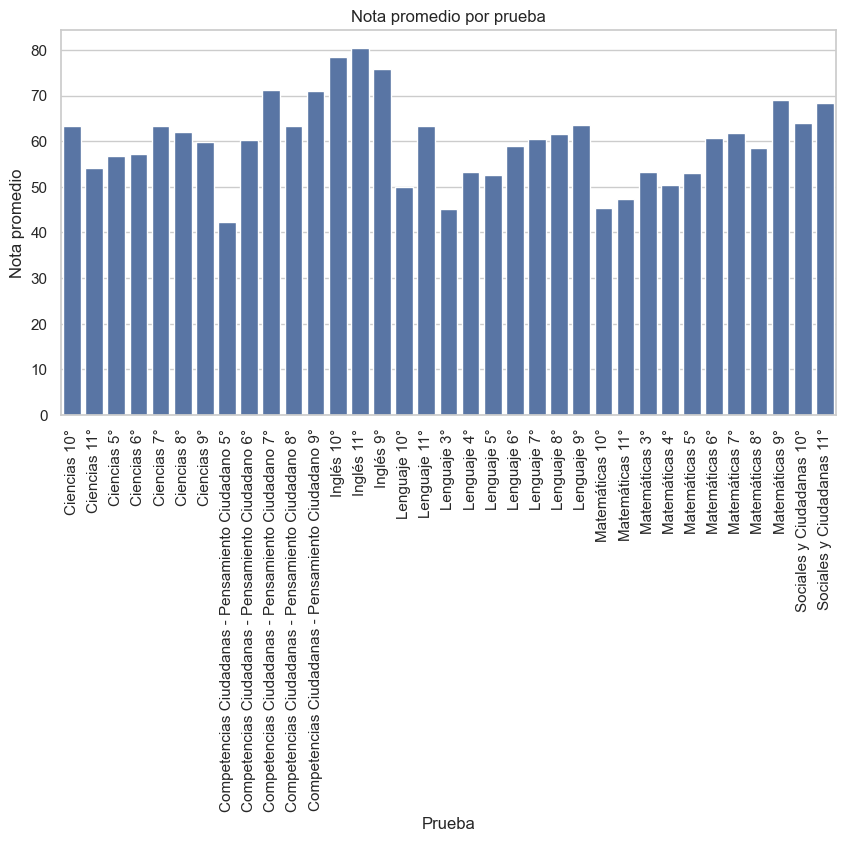

In [31]:
nota_prueba = df.groupby("Prueba")["Nota en prueba"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(data=nota_prueba, x="Prueba", y="Nota en prueba")

plt.xticks(rotation=90)

plt.title("Nota promedio por prueba")
plt.xlabel("Prueba")
plt.ylabel("Nota promedio")

plt.show()

El gráfico de desempeño promedio por prueba permite comparar el rendimiento de los estudiantes en diferentes áreas o evaluaciones. Se observa que algunas pruebas presentan promedios considerablemente más altos que otras.

Por ejemplo, evaluaciones relacionadas con Inglés tienen promedios cercanos a 75–80 puntos, lo que muestra que los estudiantes tienden a obtener mejores resultados en estas pruebas. En contraste, algunas pruebas asociadas con Lenguaje o Pensamiento Ciudadano muestran promedios más bajos, cercanos a 40–50 puntos, lo que podría indicar mayor dificultad o mayor exigencia en esas evaluaciones.

## 5. Diferencias entre grupos relevantes

Se analiza el desempeño de los estudiantes considerando variables demográficas relevantes, como el género. Esto permite explorar posibles diferencias en los resultados académicos entre distintos grupos de estudiantes.

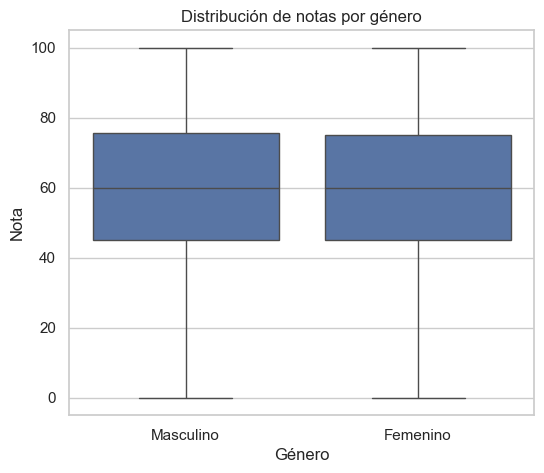

In [32]:
plt.figure(figsize=(6,5))

sns.boxplot(x="Genero", y="Nota en prueba", data=df)

plt.title("Distribución de notas por género")
plt.xlabel("Género")
plt.ylabel("Nota")

plt.show()

La distribución de notas por género permite comparar la distribución de calificaciones entre estudiantes masculinos y femeninos.

En el gráfico se observa que ambos grupos presentan medianas muy similares, cercanas a 60 puntos, y rangos de dispersión comparables. Además, los valores máximos y mínimos son prácticamente iguales en ambos grupos.

Esto sugiere que no existen diferencias significativas en el desempeño académico entre géneros dentro de este conjunto de datos. La distribución de las calificaciones parece ser bastante homogénea entre ambos grupos.

## 6. Formulación de hipótesis

A partir de los patrones observados en el análisis exploratorio, se pueden plantear algunas hipótesis que podrían explorarse en análisis posteriores:

1. El desempeño académico de los estudiantes puede variar según el grado escolar.
2. Algunas pruebas presentan mayor nivel de dificultad que otras, lo cual se refleja en promedios de nota más bajos.
3. Podrían existir diferencias en el rendimiento entre distintos grupos de estudiantes.
4. La distribución de las notas sugiere que la mayoría de los estudiantes se concentra en niveles de desempeño intermedio.

Estas hipótesis podrían evaluarse posteriormente mediante modelos de análisis predictivo o técnicas de interpretabilidad como LIME o SHAP.

## Interpretación del análisis exploratorio

### Tarea

Redactar una síntesis de los hallazgos del análisis exploratorio.

### La síntesis debe responder al menos:

1. ¿Qué patrón general se observa en las notas?
2. ¿Qué patrón general se observa en la aprobación?
3. ¿Qué grupos parecen rendir mejor o peor?
4. ¿Qué hallazgos podrían ser relevantes para el modelado?

### Producto esperado

Un texto interpretativo, no solo tablas ni gráficos.

El análisis exploratorio de los datos permitió identificar varios patrones relevantes en el desempeño académico de los estudiantes. Primero, al analizar la distribución de las notas finales se observa que la mayoría de los estudiantes obtiene calificaciones en un rango intermedio, principalmente entre 50 y 80 puntos, con un promedio cercano a 60 puntos. La distribución presenta una dispersión moderada a lo largo del rango de calificaciones, lo cual indica que existen estudiantes con desempeños diferentes, desde resultados muy bajos hasta resultados altos. Sin embargo, la mayor concentración de estudiantes se encuentra en niveles de desempeño medio.

En relación con la aprobación, el análisis muestra que la cantidad de estudiantes que aprueban y los que no aprueban es relativamente similar, aunque se observa una ligera mayor proporción de estudiantes que no aprueban. Esto indica que la variable de aprobación se encuentra balanceada, lo cual resulta positivo para posteriores tareas de modelado, especialmente si se utilizan modelos de clasificación para predecir la probabilidad de aprobación.

Al comparar el desempeño promedio entre distintos grados, se observan diferencias claras entre niveles educativos. Algunos grados presentan promedios más altos, cercanos a 65–70 puntos, mientras que otros muestran promedios alrededor de 50–55 puntos. Esto sugiere que el rendimiento académico puede variar dependiendo del nivel educativo, posiblemente debido a la dificultad de los contenidos evaluados o a diferencias en el desarrollo académico de los estudiantes. En cambio, al analizar la distribución de notas por género, no se observan diferencias entre estudiantes masculinos y femeninos, ya que ambos grupos presentan distribuciones de notas muy similares.

Por otro lado, el análisis del desempeño promedio por tipo de prueba muestra variaciones importantes entre distintas evaluaciones. Algunas pruebas presentan promedios relativamente altos, lo que podría indicar que son más accesibles para los estudiantes, mientras que otras muestran promedios más bajos, lo cual sugiere mayor nivel de dificultad o mayor exigencia conceptual. Este tipo de análisis permite identificar áreas en las que los estudiantes presentan mayores dificultades y podría ser útil para orientar estrategias pedagógicas.

Por ultimo, estos hallazgos resultan relevantes para el modelado predictivo que se realizará posteriormente. La presencia de diferencias entre grados y entre tipos de prueba sugiere que variables como el grado académico, la prueba aplicada y otras características del contexto educativo podrían ser factores importantes para predecir el desempeño o la probabilidad de aprobación. Además, el hecho de que la variable de aprobación esté relativamente balanceada facilita el entrenamiento de modelos de clasificación sin requerir técnicas adicionales para manejar desbalances extremos.

# Parte 3. Diseño de modelos predictivos

## Objetivo

Construir dos enfoques diferentes y compararlos críticamente.

---

## Tareas

1. Definir qué variables entran en el modelo base.
2. Definir qué variables adicionales entran en el modelo de alerta temprana.
3. Justificar cada decisión.
4. Explicar por qué algunas variables quedan excluidas.

### Preguntas orientadoras

- ¿Qué significa predecir “antes” frente a predecir “durante” la prueba?
- ¿Qué variables son razonables en cada escenario?

### Producto esperado

Un diseño metodológico explícito para ambos modelos.

# Parte 4. Modelo de clasificación

## Objetivo

Predecir si un estudiante aprueba o no aprueba el test o una pregunta.

---

## Tareas

1. Definir la variable objetivo de clasificación.
2. Preparar el conjunto de datos para clasificación.
3. Separar entrenamiento y prueba.
4. Justificar la forma de partición usada.
5. Entrenar un modelo base.
6. Entrenar un modelo de alerta temprana.
7. Comparar el rendimiento de ambos.

### Métricas sugeridas

- accuracy
- precision
- recall
- F1
- matriz de confusión

### Preguntas orientadoras

- ¿Qué modelo clasifica mejor?
- ¿Qué errores comete cada uno?
- ¿El mejor desempeño implica mejor diseño metodológico?

### Producto esperado

Comparación entre ambos modelos y una interpretación crítica de sus resultados.

## Interpretación del modelo de clasificación

### Tarea

Redactar una interpretación de los resultados del modelo de clasificación.

### La interpretación debe incluir

1. Qué tan bien clasifica el modelo base.
2. Qué tan bien clasifica el modelo de alerta temprana.
3. Qué diferencias aparecen entre ambos.
4. Qué conclusiones metodológicas se desprenden.

### Producto esperado

Un texto comparativo con mirada crítica.

# Parte 5. Modelo de regresión

## Objetivo

Predecir la nota final obtenida en la prueba.

---

## Tareas

1. Definir la variable objetivo de regresión.
2. Preparar el conjunto de datos para regresión.
3. Entrenar un modelo base.
4. Entrenar un modelo de alerta temprana.
5. Comparar ambos modelos.

### Métricas sugeridas

- MAE
- RMSE
- R²

### Preguntas orientadoras

- ¿Qué modelo predice mejor la nota?
- ¿Cuánto mejora al incorporar información temprana?
- ¿Es una mejora pequeña, moderada o grande?

### Producto esperado

Una comparación razonada entre ambos enfoques de regresión.

## Interpretación del modelo de regresión

### Tarea

Redactar una interpretación de los resultados del modelo de regresión.

### La interpretación debe responder

1. ¿Qué tan preciso es el modelo base?
2. ¿Qué tan preciso es el modelo de alerta temprana?
3. ¿Qué implicaciones tiene esa diferencia?
4. ¿Qué utilidad real tendría este tipo de modelo?

### Producto esperado

Un texto interpretativo, no solo un reporte de métricas.

# Parte 6. Selección de un caso individual para interpretar

## Objetivo

Elegir una observación específica del conjunto de prueba para analizarla en detalle con herramientas de explicabilidad.

---

## Tareas

1. Seleccionar un caso individual.
2. Mostrar su valor real.
3. Mostrar la predicción del modelo.
4. Justificar por qué ese caso resulta interesante para interpretar.

### Preguntas orientadoras

- ¿Conviene elegir un caso típico o uno llamativo?
- ¿Conviene elegir un acierto del modelo o un error?

### Producto esperado

Un caso claramente identificado para el análisis con LIME y SHAP.

# Parte 7. Interpretación con LIME

## Objetivo

Explicar localmente por qué el modelo realizó una predicción específica.

---

## Tareas

1. Aplicar LIME al caso seleccionado.
2. Revisar qué variables empujan la predicción en una dirección y cuáles en otra.
3. Describir la explicación con palabras.

### Preguntas orientadoras

- ¿Qué variables favorecen el resultado predicho?
- ¿Qué variables lo debilitan?
- ¿La explicación parece coherente con la lógica del problema?

### Producto esperado

Una interpretación escrita de la explicación local de LIME.

## Interpretación escrita de LIME

### Tarea

Redactar una explicación textual de la gráfica de LIME.

### La redacción debe incluir

1. Si la explicación es local o global.
2. Qué factores empujan más a favor del resultado.
3. Qué factores empujan más en contra.
4. Una síntesis narrativa del caso.

### Producto esperado

Un texto claro, interpretativo y bien argumentado.

# Parte 8. Interpretación con SHAP local

## Objetivo

Explicar un caso individual usando contribuciones aditivas.

---

## Tareas

1. Aplicar SHAP local al caso seleccionado.
2. Identificar el valor base.
3. Identificar la suma de contribuciones.
4. Verificar cómo se reconstruye la predicción final.
5. Analizar qué variables tienen mayor contribución positiva y negativa.

### Preguntas orientadoras

- ¿Qué significa el valor base?
- ¿Qué significa que una contribución sea positiva o negativa?
- ¿Qué diferencia hay entre esta lógica y la de LIME?

### Producto esperado

Una interpretación escrita de la explicación local de SHAP.

## Interpretación escrita de SHAP local

### Tarea

Redactar una explicación textual de la gráfica local de SHAP.

### La redacción debe incluir

1. El significado del valor base.
2. El papel de las contribuciones individuales.
3. Qué variables suben o bajan la predicción.
4. Una síntesis narrativa del caso.

### Producto esperado

Un texto claro y técnicamente correcto.

# Parte 9. Interpretación con SHAP global

## Objetivo

Analizar el comportamiento general del modelo en múltiples observaciones.

---

## Tareas

1. Construir una explicación global con SHAP.
2. Identificar qué variables aparecen como más influyentes.
3. Comparar la explicación global con la explicación local del caso individual.

### Preguntas orientadoras

- ¿Qué variables tienen mayor impacto global?
- ¿Coinciden con las variables importantes del caso individual?
- ¿Puede una variable ser importante globalmente y no localmente, o viceversa?

### Producto esperado

Una interpretación del comportamiento global del modelo.

## Comparación entre LIME y SHAP

### Tarea

Redactar una comparación entre ambas herramientas.

### La comparación debe responder

1. ¿Qué cuentan en común?
2. ¿En qué se diferencian?
3. ¿Cuál resulta más intuitiva para este caso?
4. ¿Cómo cambia la interpretación cuando se pasa de lo local a lo global?

### Producto esperado

Un texto comparativo entre LIME y SHAP.

# Parte 11. Discusión crítica

## Objetivo

Reflexionar sobre los límites metodológicos, éticos y prácticos del análisis.

---

## Tareas

Responder de forma argumentada:

1. ¿Qué variables pueden introducir fuga de información?
2. ¿Qué riesgos tiene usar variables sensibles como género, curso o sede?
3. ¿Interpretar un modelo implica que la relación sea causal?
4. ¿Este tipo de análisis sería útil para intervención temprana, monitoreo o solo descripción?
5. ¿Qué limitaciones de la base podrían afectar las conclusiones?
6. ¿Qué otras variables usaría y cómo?

### Producto esperado

Un texto crítico final.